In [7]:
# import pandas as pd
# import numpy as np

In [8]:
filepath='../data/combined+cycle+power+plant/CCPP/Folds5x2_pp.xlsx'
df = pd.read_excel(filepath)

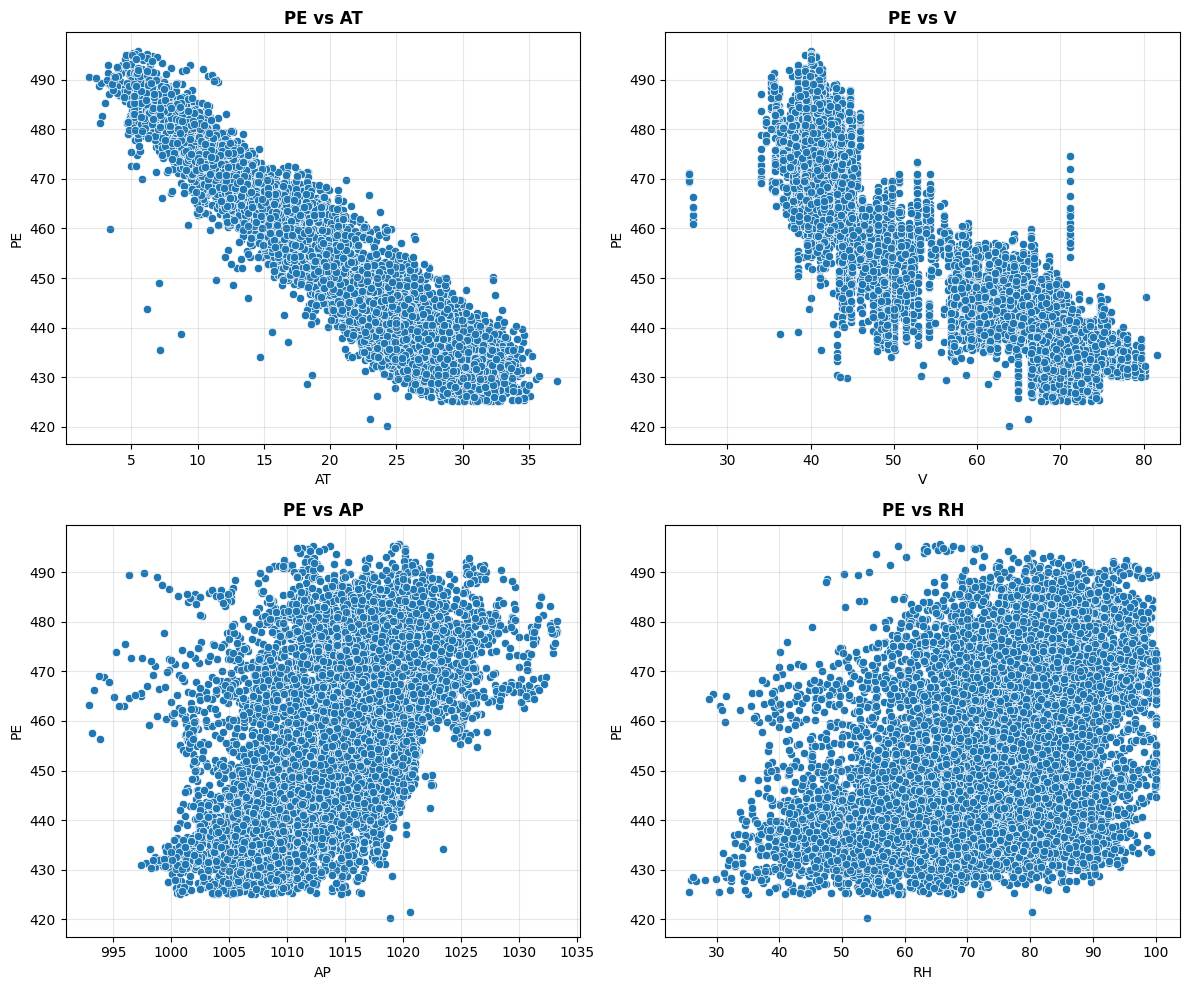

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

X_cols = ['AT', 'V', 'AP', 'RH']
y_col = 'PE'

for i, x_col in enumerate(X_cols):
    sns.scatterplot(data=df, y=y_col, x=x_col, ax=axes[i])
    axes[i].set_title(f'{y_col} vs {x_col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(x_col, fontsize=10)
    axes[i].set_ylabel(y_col, fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Images/variable_plot.png')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

y_col, X_col = 'PE', 'V'

df = df_o[[X_col, y_col]].dropna()

X = np.asarray(df[[X_col]])
y = np.asarray(df[y_col])

data = {'X': X.reshape(1,-1)[0],'y': y}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

data_train = {'X': X_train.reshape(-1, 1)[0],'y': y_train}
data_test = {'X': X_test.reshape(-1, 1)[0],'y': y_test}

np.savez_compressed('split_data.npz', 
                    X_train=X_train, y_train=y_train, 
                    X_test=X_test, y_test=y_test)

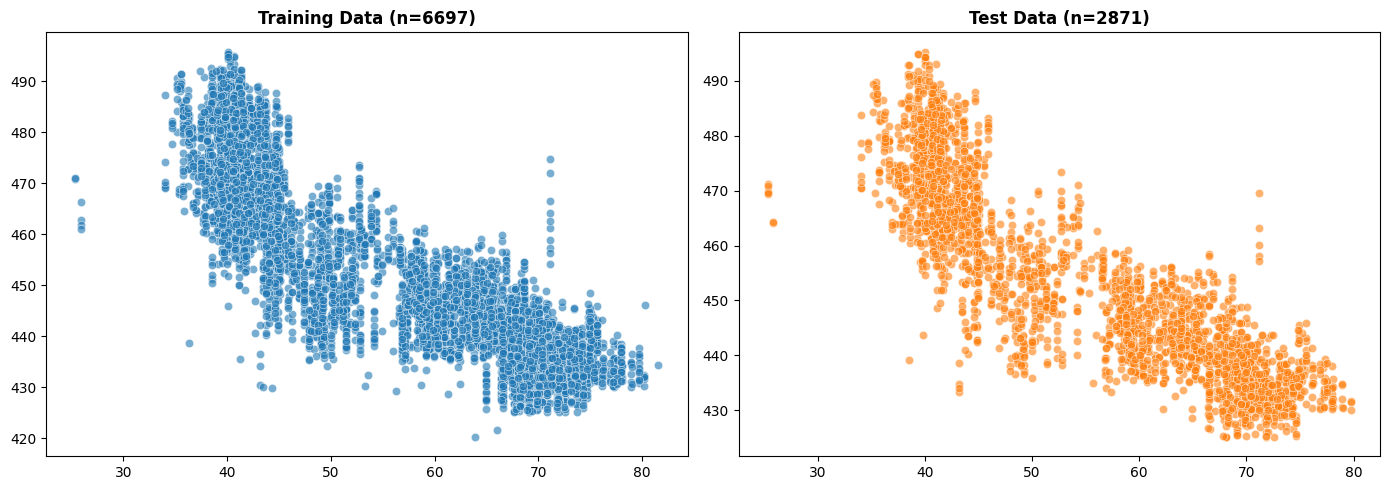

In [14]:
# Get seaborn's default color palette
default_colors = sns.color_palette()
seaborn_blue = default_colors[0]
seaborn_orange = default_colors[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data with blue
sns.scatterplot(x=X_train.flatten(), y=y_train, ax=axes[0], color=seaborn_blue, alpha=0.6)
axes[0].set_title(f'Training Data (n={len(X_train)})', fontweight='bold')

# Test data with orange
sns.scatterplot(x=X_test.flatten(), y=y_test, ax=axes[1], color=seaborn_orange, alpha=0.6)
axes[1].set_title(f'Test Data (n={len(X_test)})', fontweight='bold')

plt.tight_layout()
plt.savefig('Images/train_test.png')
plt.show()